# Évaluation CL — TinyOL — Dataset 2 Equipment Monitoring — by_equipment

| Champ | Valeur |
|-------|--------|
| **Modèle** | TinyOL (encodeur 4→8→8→8 = 184 params + tête OtO 10 params = 194 total) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_equipment : Pump → Turbine → Compressor (3 tâches) |
| **Expérience** | exp_011 — voir experiments/exp_011_tinyol_monitoring_by_equipment/config_snapshot.yaml |
| **Sprint** | 7 — S7-01 |

> **Modèle supervisé** : TinyOL combine un autoencoder gelé + une tête OtO (One-to-One) entraînable en ligne.
> Sortie = probabilité de défaut ŷ ∈ [0, 1] (sigmoid).
> Stratégie CL : architecture-based — seule la tête (10 params) est mise à jour sample-by-sample (SGD pur, sans momentum).
> RAM totale = 4.3 Ko (backbone Flash + tête RAM) — confortable dans le budget 64 Ko STM32N6.

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_by_equipment/tinyol.ipynb \
    --output /tmp/tinyol_executed.ipynb --ExecutePreprocessor.timeout=600
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_equipment":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import fit_pca2d, plot_feature_space_2d

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_011_tinyol_monitoring_by_equipment/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/tinyol/monitoring/by_equipment"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE_CKPT   = REPO_ROOT / "experiments/exp_011_tinyol_monitoring_by_equipment/backbone.pt"
CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer.yaml"
CONFIG_PATH     = REPO_ROOT / "configs/tinyol_monitoring_config.yaml"

# --- Constantes ---
TASK_NAMES     = ["Pump", "Turbine", "Compressor"]
MODEL_NAME     = "TinyOL"
DATA_AVAILABLE = CSV_PATH.exists() and BACKBONE_CKPT.exists() and CONFIG_PATH.exists()

print(f"REPO_ROOT         : {REPO_ROOT}")
print(f"EXP_DIR           : {EXP_DIR}")
print(f"FIGURES_DIR       : {FIGURES_DIR}")
print(f"CSV disponible    : {CSV_PATH.exists()}")
print(f"Backbone .pt      : {BACKBONE_CKPT.exists()}")
print(f"Config disponible : {CONFIG_PATH.exists()}")
print(f"Date exécution    : {datetime.now():%Y-%m-%d %H:%M}")

if not DATA_AVAILABLE:
    display(Markdown(
        "> ⚠️ **Ressources absentes** — Sections 5, 6, 7, 8 en mode dégradé (données synthétiques). "
        "Placer `equipment_anomaly_data.csv`, `backbone.pt` et `tinyol_monitoring_config.yaml` pour le mode complet."
    ))

REPO_ROOT         : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR           : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_011_tinyol_monitoring_by_equipment/results
FIGURES_DIR       : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/tinyol/monitoring/by_equipment
CSV disponible    : True
Backbone .pt      : True
Config disponible : True
Date exécution    : 2026-04-19 10:42


In [2]:
# Section 2 — Chargement des résultats exp_011
# Spécificité TinyOL : metrics.json a une structure plate (acc_final, avg_forgetting, backward_transfer)
# et la matrice d'accuracy est embedded dans le JSON en lower-triangular (pas de .npy séparé)

metrics_path = EXP_DIR / "metrics.json"
metrics      = json.loads(metrics_path.read_text())

# Reconstruire la matrice 3×3 avec NaN dans le triangle supérieur
acc_matrix_raw = metrics["acc_matrix"]  # liste lower-triangular : rows de longueurs 1, 2, 3
n_tasks = len(acc_matrix_raw)
acc_matrix_json = np.full((n_tasks, n_tasks), np.nan, dtype=float)
for i, row in enumerate(acc_matrix_raw):
    for j, v in enumerate(row):
        acc_matrix_json[i, j] = v

aa  = metrics["acc_final"]
af  = metrics["avg_forgetting"]
bwt = metrics["backward_transfer"]
ram_b = metrics["ram_peak_bytes"]
lat   = metrics["inference_latency_ms"]
n_encoder = metrics.get("n_params_encoder", 184)
n_oto     = metrics.get("n_params_oto", 10)
n_params  = n_encoder + n_oto
within_budget = ram_b <= 65536

print("=" * 55)
print(f"  Modèle         : TinyOL (autoencoder gelé + tête OtO)")
print(f"  AA             = {aa:.4f}")
print(f"  AF             = {af:.4f}")
print(f"  BWT            = {bwt:+.4f}")
print(f"  RAM peak       = {ram_b} B ({ram_b/1024:.2f} Ko)")
print(f"  Latence        = {lat:.5f} ms")
print(f"  n_params       = {n_params}  (encodeur={n_encoder} + OtO={n_oto})")
print(f"  Budget 64 Ko   : {within_budget}")
print("=" * 55)
print("\nMatrice acc (3×3) :")
print(acc_matrix_json)

  Modèle         : TinyOL (autoencoder gelé + tête OtO)
  AA             = 0.9123
  AF             = 0.0079
  BWT            = -0.0029
  RAM peak       = 4379 B (4.28 Ko)
  Latence        = 0.00975 ms
  n_params       = 194  (encodeur=184 + OtO=10)
  Budget 64 Ko   : True

Matrice acc (3×3) :
[[0.91021214        nan        nan]
 [0.92007893 0.92153996        nan]
 [0.91119882 0.91471735 0.91107872]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/tinyol/monitoring/by_equipment/acc_matrix.png


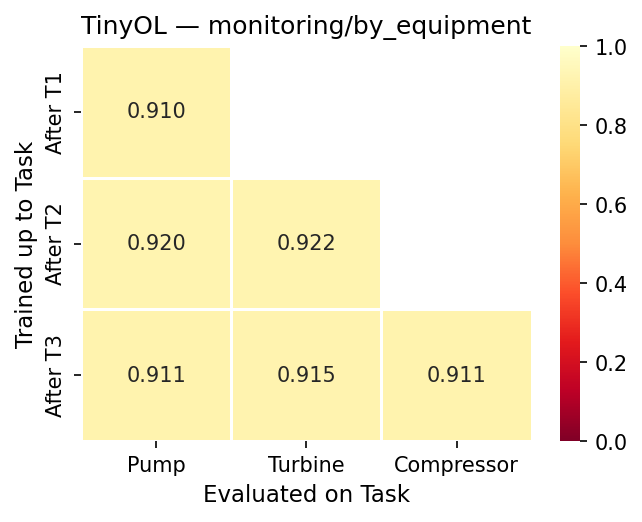

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)
# acc_matrix[i, j] = accuracy sur tâche j après entraînement sur tâche i
# Diagonale = perf immédiate post-training, sous-diagonale = oubli

fig = plot_accuracy_matrix(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_equipment",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/tinyol/monitoring/by_equipment/forgetting_curve.png


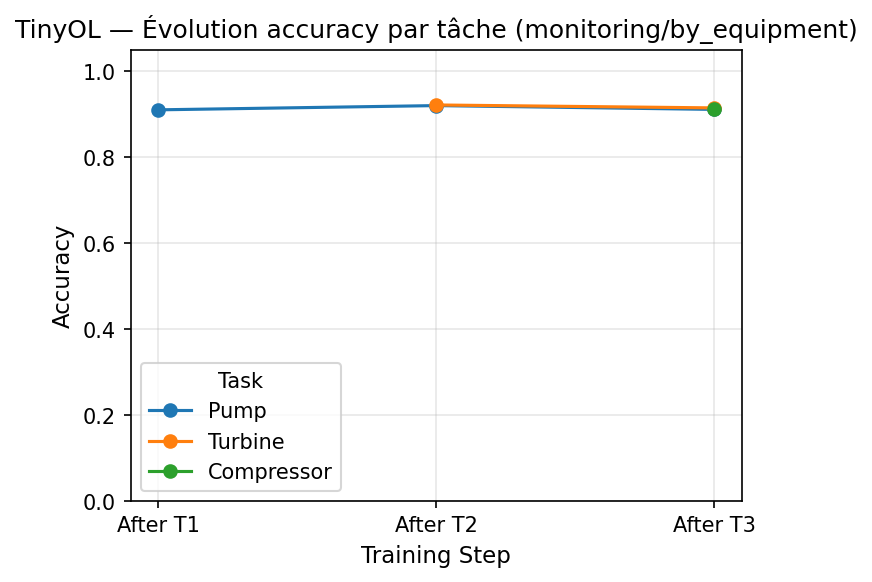

In [4]:
# Section 4 — Courbe d'oubli par tâche
# AF ≈ 0.0079 → légère dégradation sur les tâches anciennes
# TinyOL architecture-based : seule la tête OtO est mise à jour (10 params),
# l'encodeur gelé garantit la stabilité des features

fig = plot_forgetting_curve(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (monitoring/by_equipment)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

In [5]:
# Section 5 — Rejeu du scénario CL (collecte preds_dict + proba_dict)
# Reproduit exp_011 : charge le backbone pré-entraîné (backbone.pt),
# instancie une tête OtO fraîche, et effectue l'apprentissage online (batch_size=1, SGD lr=0.01)
# Nécessaire pour les matrices de confusion (S6), les courbes ROC (S7) et la PCA (S8)

preds_dict  = {}  # (i, j) → (y_true, y_pred_binary)
proba_dict  = {}  # (i, j) → sigmoid outputs float32  (pour ROC)
X_tests_raw = []  # [N_val, 4] par tâche — pour la viz PCA
y_tests_raw = []  # [N_val] par tâche

if DATA_AVAILABLE:
    from src.data.monitoring_dataset import get_cl_dataloaders
    from src.models.tinyol.autoencoder import TinyOLAutoencoder
    from src.models.tinyol.oto_head import OtOHead, TinyOLOnlineTrainer
    from src.utils.reproducibility import set_seed

    set_seed(42)

    # Charger la config exp_011
    config = yaml.safe_load(CONFIG_PATH.read_text())
    encoder_dims = tuple(config["backbone"]["encoder_dims"])
    decoder_dims = tuple(config["backbone"]["decoder_dims"])
    input_dim    = config["backbone"]["input_dim"]

    # Instancier le backbone + charger le checkpoint gelé
    autoencoder = TinyOLAutoencoder(
        input_dim=input_dim,
        encoder_dims=encoder_dims,
        decoder_dims=decoder_dims,
    )
    autoencoder.load_state_dict(torch.load(BACKBONE_CKPT, map_location="cpu"))
    autoencoder.freeze_encoder()

    # Tête OtO fraîche (input = embed_dim + 1 MSE = 9)
    oto_head = OtOHead(input_dim=config["oto_head"]["input_dim"])
    trainer = TinyOLOnlineTrainer(autoencoder, oto_head, config)

    # Dataloaders (batch_size=1 pour online strict)
    tasks = get_cl_dataloaders(
        csv_path=CSV_PATH,
        normalizer_path=NORMALIZER_PATH,
        batch_size=1,
        seed=42,
    )

    # Extraire les données de validation en numpy une seule fois
    for t in tasks:
        X_v = np.concatenate([b[0].numpy() for b in t["val_loader"]])
        y_v = np.concatenate([b[1].numpy().flatten() for b in t["val_loader"]])
        X_tests_raw.append(X_v)
        y_tests_raw.append(y_v)

    def predict_all(X_np):
        '''Retourne (probas, preds) pour un batch [N, 4] numpy.'''
        probas = np.zeros(len(X_np), dtype=np.float32)
        for idx, sample in enumerate(X_np):
            p, _ = trainer.predict(torch.from_numpy(sample).float())
            probas[idx] = p
        preds = (probas >= 0.5).astype(float)
        return probas, preds

    for i, task in enumerate(tasks):
        domain = task.get("domain", f"Tâche {task['task_id']}")
        print(f"\n--- Tâche {i + 1}/3 : {domain} ---")

        # Apprentissage online : 1 pass, sample-by-sample
        losses = []
        for x_batch, y_batch in task["train_loader"]:
            # batch_size=1 : x_batch.shape=[1,4], y_batch.shape=[1] ou [1,1]
            loss = trainer.update(x_batch.squeeze(0), y_batch.squeeze().float())
            losses.append(loss)
        print(f"  Loss moyenne tâche : {np.mean(losses):.4f} (N={len(losses)})")

        # Évaluation sur toutes les tâches vues jusqu'à i
        for j in range(i + 1):
            probas, y_pred = predict_all(X_tests_raw[j])
            preds_dict[(i, j)] = (y_tests_raw[j], y_pred)
            proba_dict[(i, j)] = probas
            acc = (y_tests_raw[j] == y_pred).mean()
            print(f"  preds_dict[({i},{j})] → N={len(y_tests_raw[j])}, acc={acc:.4f}")

    print(f"\nScénario CL rejoué — {len(preds_dict)} évaluations collectées")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — ressources absentes. preds_dict synthétique depuis acc_matrix."))

    # Reconstruction approchée depuis acc_matrix_json
    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(N_SYNTH // 2), np.ones(N_SYNTH // 2)])

    for i in range(3):
        for j in range(i + 1):
            acc_ij = acc_matrix_json[i, j]
            noise = rng.normal(0, 0.1, N_SYNTH)
            probas_synth = np.where(y_synth == 1, 0.70 + noise, 0.30 + noise).clip(0, 1)
            y_pred_synth = (probas_synth >= 0.5).astype(float)
            preds_dict[(i, j)] = (y_synth.copy(), y_pred_synth)
            proba_dict[(i, j)] = probas_synth.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé)")

✅ Seed fixé à 42


✅ Seed fixé à 42

--- Tâche 1/3 : Pump ---


/home/leonard/.local/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Loss moyenne tâche : 0.4288 (N=2027)
  preds_dict[(0,0)] → N=507, acc=0.9053

--- Tâche 2/3 : Turbine ---


  Loss moyenne tâche : 0.3112 (N=2052)
  preds_dict[(1,0)] → N=507, acc=0.9270
  preds_dict[(1,1)] → N=513, acc=0.9220

--- Tâche 3/3 : Compressor ---


  Loss moyenne tâche : 0.2855 (N=2058)
  preds_dict[(2,0)] → N=507, acc=0.9310
  preds_dict[(2,1)] → N=513, acc=0.9240
  preds_dict[(2,2)] → N=515, acc=0.9417

Scénario CL rejoué — 6 évaluations collectées


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/tinyol/monitoring/by_equipment/confusion_matrix_grid.png


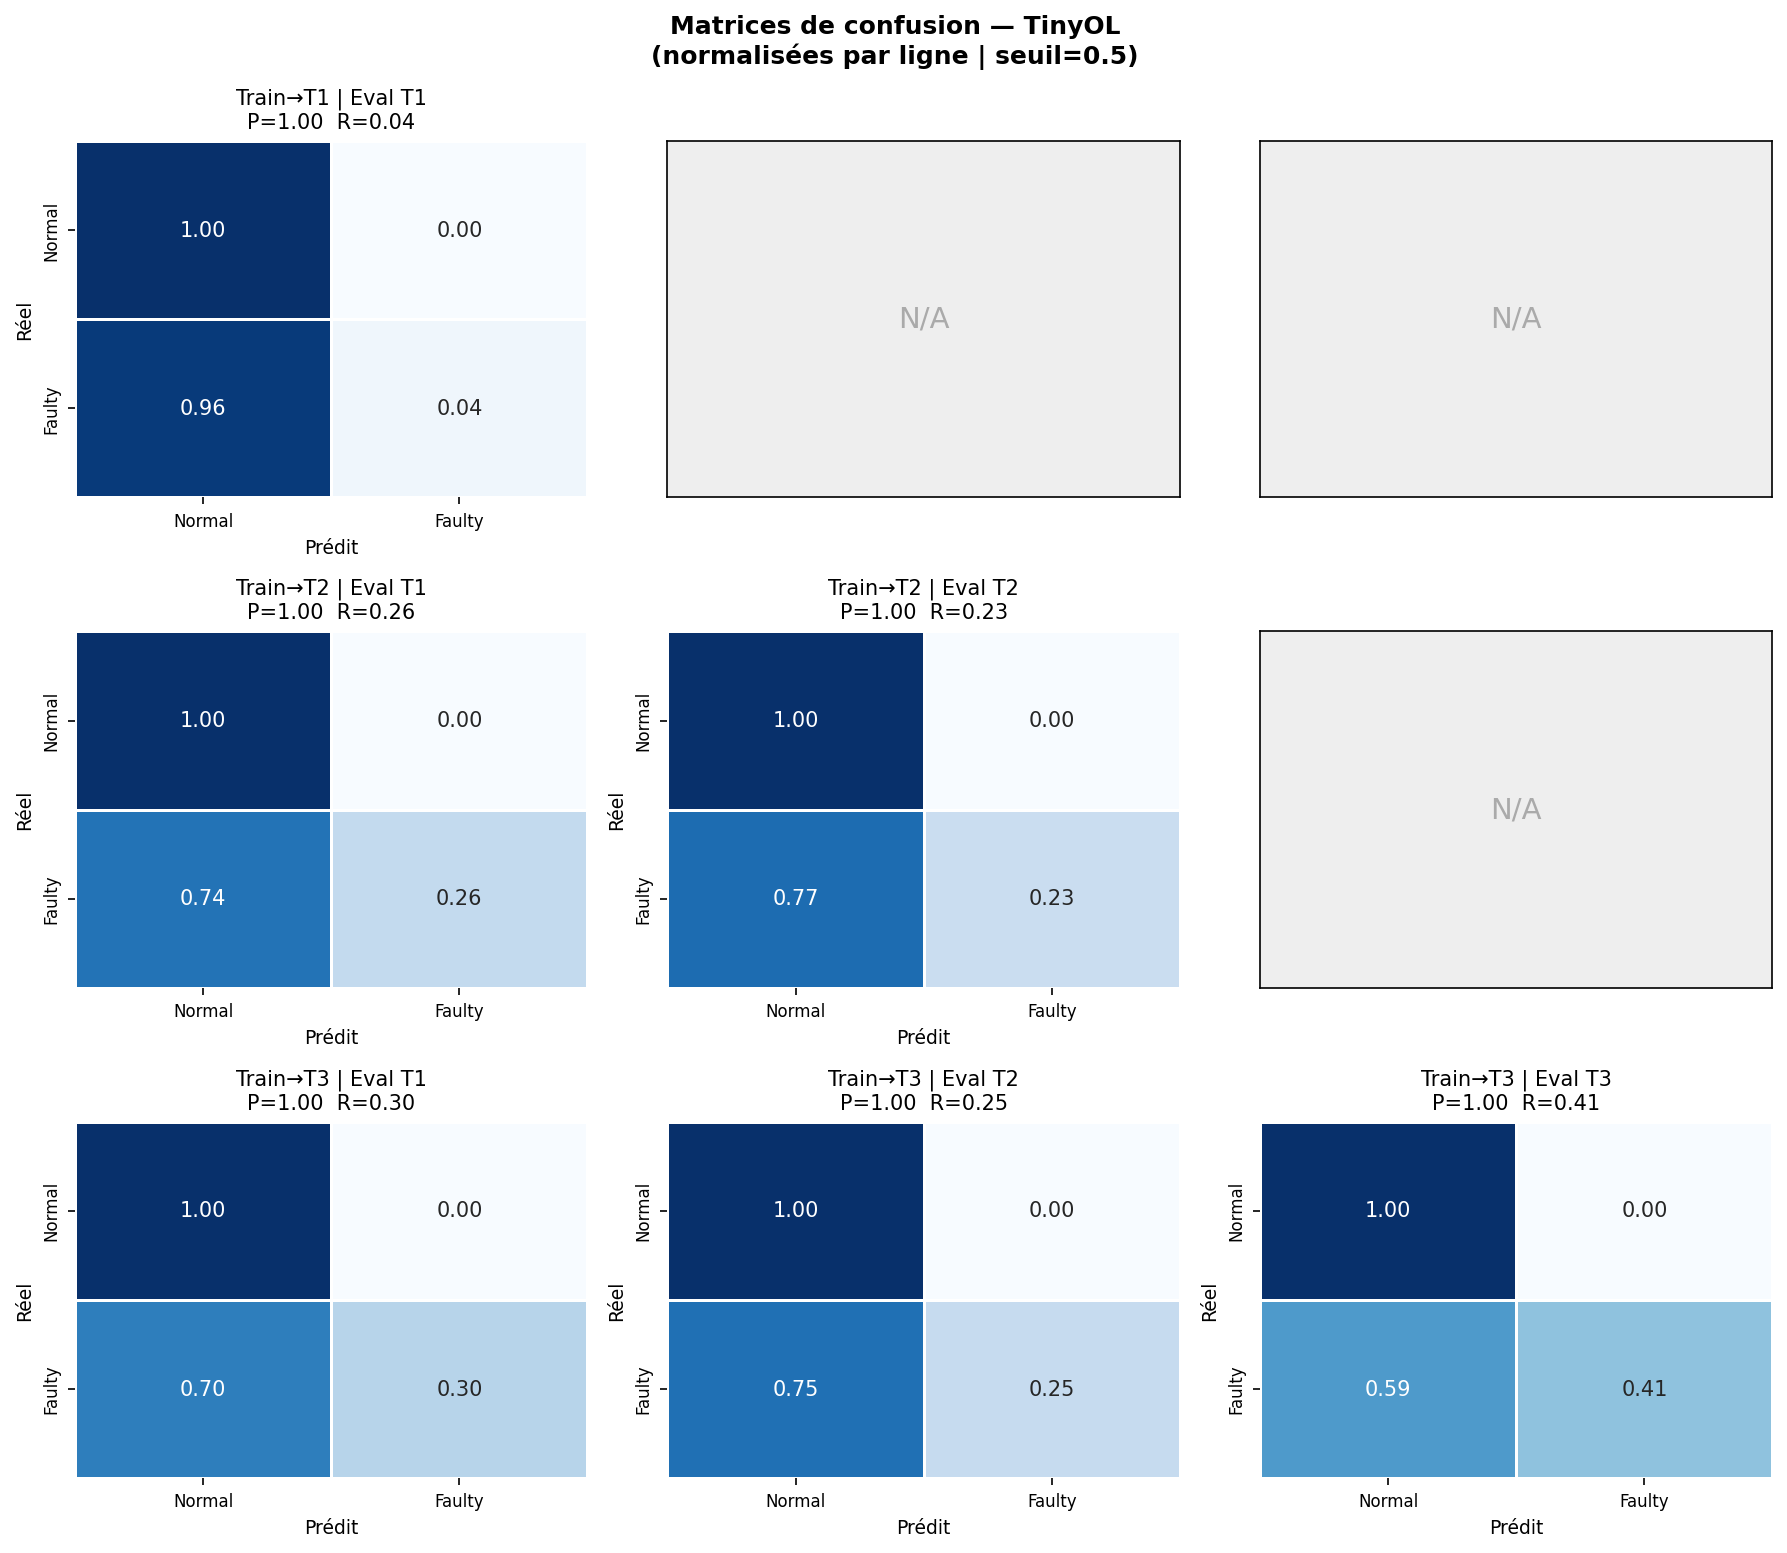

In [6]:
# Section 6 — Matrices de confusion par tâche (grille 3×3)
# Ligne i = état du modèle après entraînement sur tâche i
# Colonne j = évaluation sur tâche j
# Cellule (i,j) avec j > i = grisée (tâche pas encore vue)
# Normalisées par ligne (recall par classe)

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/tinyol/monitoring/by_equipment/roc_curves.png


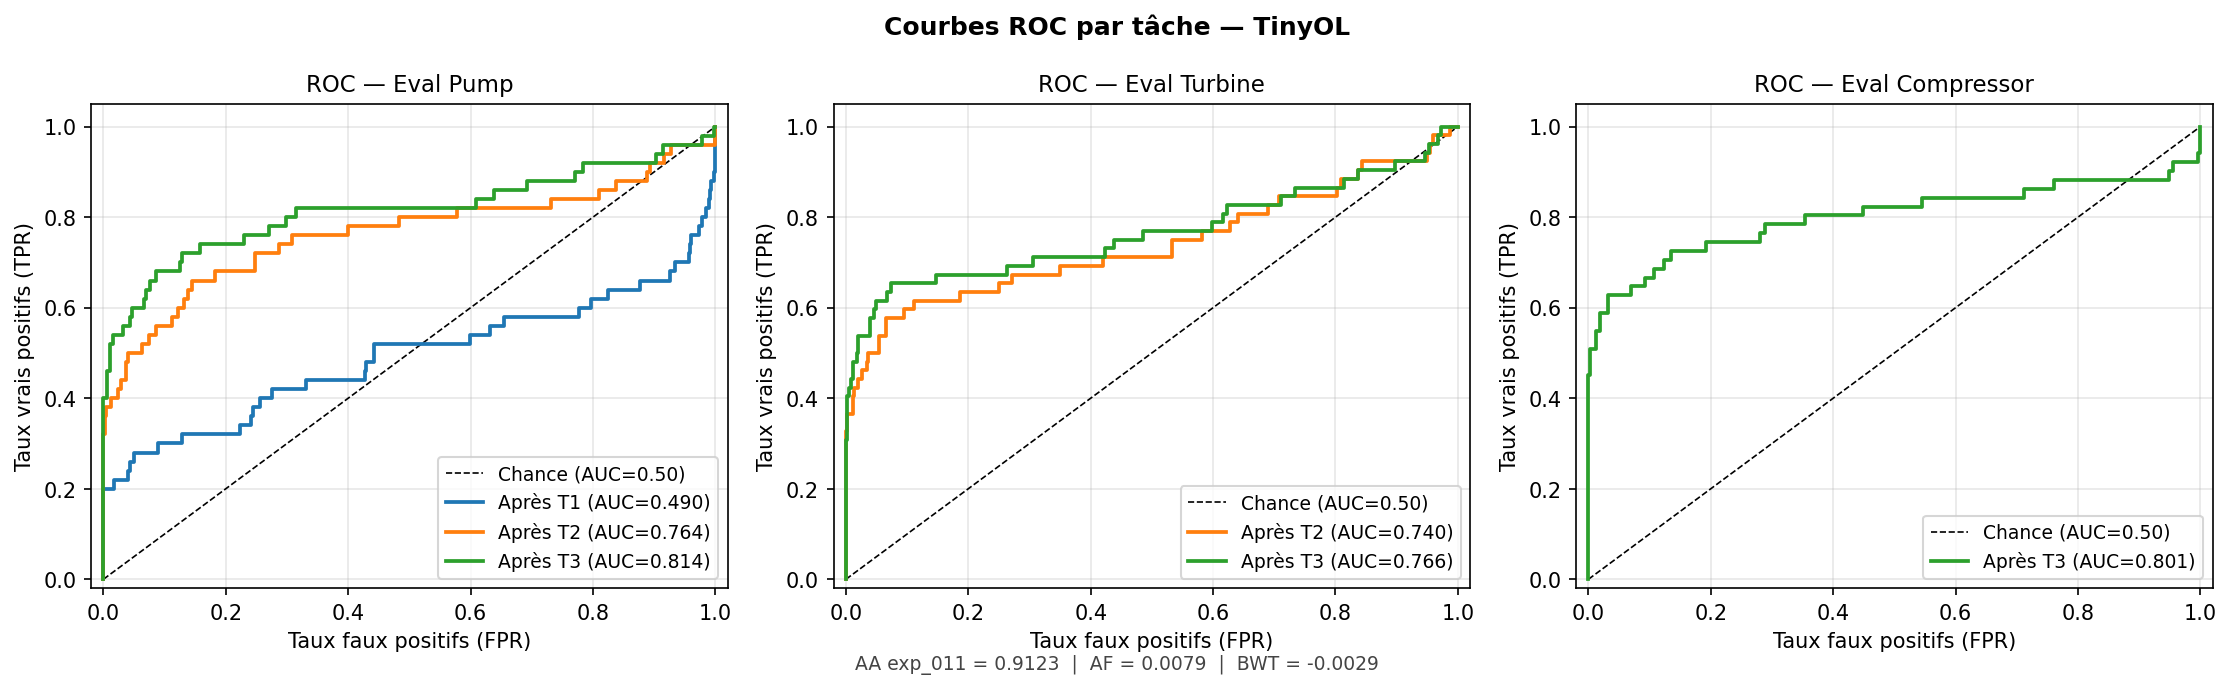

In [7]:
# Section 7 — Courbes ROC par tâche
# TinyOL tête OtO = classifieur supervisé → sorties sigmoid = scores de probabilité continus
# Une courbe par step d'entraînement sur chaque tâche j (courbes superposées)

fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=proba_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)

# Footer : AA final exp_011 pour référence
fig.text(
    0.5, 0.01,
    f"AA exp_011 = {aa:.4f}  |  AF = {af:.4f}  |  BWT = {bwt:+.4f}",
    ha="center", fontsize=9, color="#444444",
)

save_figure(fig, FIGURES_DIR / "roc_curves.png")
display(Image(str(FIGURES_DIR / "roc_curves.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/tinyol/monitoring/by_equipment/feature_space_pca.png


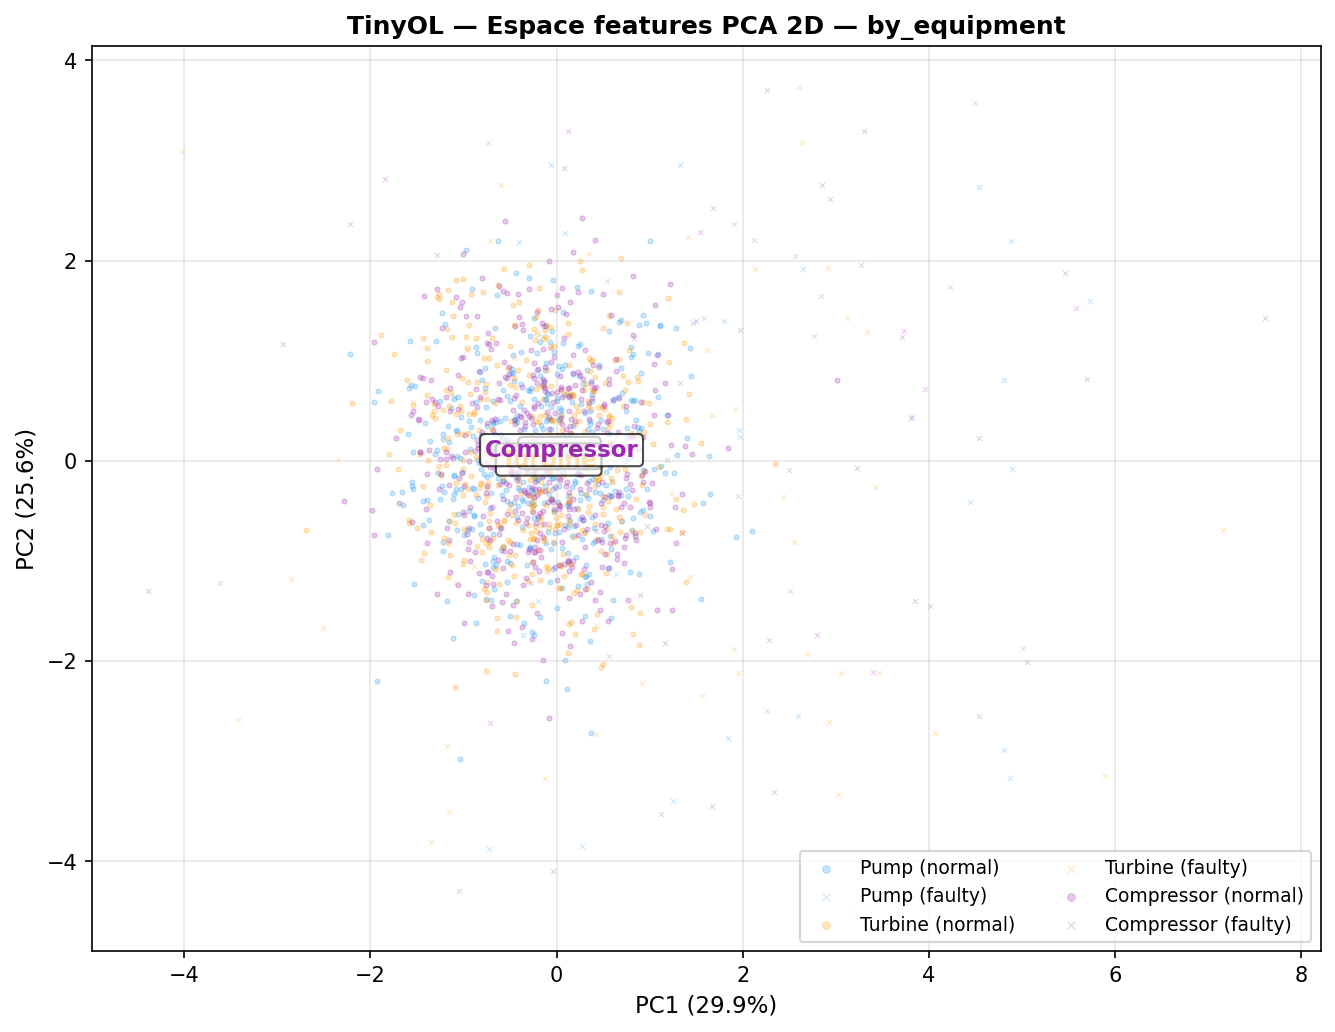

In [8]:
# Section 8 — Espace des features (PCA 2D)
# Visualise la distribution des 3 tâches dans l'espace 2D PCA
# Coloré par tâche (domain_ids) et par label (normal/faulty)

if DATA_AVAILABLE and len(X_tests_raw) == 3:
    X_all      = np.concatenate(X_tests_raw, axis=0)
    y_all      = np.concatenate(y_tests_raw, axis=0)
    domain_ids = np.concatenate([
        np.full(len(X_tests_raw[k]), k) for k in range(3)
    ])

    pca, X_proj = fit_pca2d(X_all)
    expl_var = pca.explained_variance_ratio_
    xlabel = f"PC1 ({expl_var[0]*100:.1f}%)"
    ylabel = f"PC2 ({expl_var[1]*100:.1f}%)"

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_feature_space_2d(
        X_proj, y_all,
        title=f"{MODEL_NAME} — Espace features PCA 2D — by_equipment",
        ax=ax,
        domain_ids=domain_ids,
        alpha=0.25,
        s=6,
        xlabel=xlabel,
        ylabel=ylabel,
    )

    TASK_COLORS = ["#2196F3", "#FF9800", "#9C27B0"]
    for k, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
        mask = domain_ids == k
        cx, cy = X_proj[mask, 0].mean(), X_proj[mask, 1].mean()
        ax.annotate(
            name,
            xy=(cx, cy),
            fontsize=11,
            fontweight="bold",
            color=color,
            ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.tight_layout()
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown(
        "> ⚠️ **Section 8 ignorée** — CSV absent ou scénario CL non rejoué. "
        "feature_space_pca.png non généré."
    ))
    print("[SKIP] feature_space_pca.png — données non disponibles.")

In [9]:
# Section 9 — Tableau récapitulatif + critères d'acceptation

ram_ko = ram_b / 1024

display(Markdown("### Résultats finaux — TinyOL — monitoring/by_equipment (exp_011)"))

recap_table = f'''
| Modèle | AA ↑ | AF ↓ | BWT | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {ram_ko:.2f} Ko | {lat:.5f} ms | {n_params} |
'''
display(Markdown(recap_table))

print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)")
print("=" * 60)
print(f"  RAM = {ram_b} B = {ram_ko:.2f} Ko")
print(f"  Budget STM32N6 : 65 536 B (64 Ko)")
print(f"  Marge disponible : {65536 - ram_b} B ({(65536 - ram_b)/1024:.1f} Ko)")
print(f"  TinyOL occupe {ram_b / 65536 * 100:.2f}% du budget RAM")
print()
print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 3 (architecture-based, pas de replay)")
print("=" * 60)
print(f"  Backbone gelé ({n_encoder} params) → stable en Flash")
print(f"  Tête OtO ({n_oto} params, 40 B) → seule partie entraînable online")
print(f"  Pas de régularisation Fisher, pas de buffer de replay")
print(f"  SGD pur (momentum=0.0) : conforme MCU (pas d'état Adam)")
print()
print("  TODO(arnaud) : TinyOL AA=0.9123 < EWC AA=0.9824 sur ce scénario")
print("                 — discuter le trade-off simplicité/performance dans S7-13.")
print()

# Vérification des critères d'acceptation (S7-01)
print("=" * 60)
print("  Critères d'acceptation (S7-01)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "roc_curves.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.9123) < 0.005 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.9123)")
print(f"  [{'OK' if abs(af - 0.0079) < 0.005 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0079)")
print(f"  [{'OK' if abs(bwt + 0.0029) < 0.005 else 'WARN'}] BWT    = {bwt:+.4f} (attendu ≈ -0.0029)")
print(f"  [{'OK' if ram_b <= 65536 else 'FAIL'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

### Résultats finaux — TinyOL — monitoring/by_equipment (exp_011)


| Modèle | AA ↑ | AF ↓ | BWT | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|-------|-----------|----------|
| TinyOL | 0.9123 | 0.0079 | -0.0029 | 4.28 Ko | 0.00975 ms | 194 |


  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)
  RAM = 4379 B = 4.28 Ko
  Budget STM32N6 : 65 536 B (64 Ko)
  Marge disponible : 61157 B (59.7 Ko)
  TinyOL occupe 6.68% du budget RAM

  NOTE SCIENTIFIQUE — Gap 3 (architecture-based, pas de replay)
  Backbone gelé (184 params) → stable en Flash
  Tête OtO (10 params, 40 B) → seule partie entraînable online
  Pas de régularisation Fisher, pas de buffer de replay
  SGD pur (momentum=0.0) : conforme MCU (pas d'état Adam)

  TODO(arnaud) : TinyOL AA=0.9123 < EWC AA=0.9824 sur ce scénario
                 — discuter le trade-off simplicité/performance dans S7-13.

  Critères d'acceptation (S7-01)
  [OK] acc_matrix.png
  [OK] forgetting_curve.png
  [OK] confusion_matrix_grid.png
  [OK] roc_curves.png
  [OK] feature_space_pca.png

  [OK] AA     = 0.9123  (attendu ≈ 0.9123)
  [OK] AF     = 0.0079  (attendu ≈ 0.0079)
  [OK] BWT    = -0.0029 (attendu ≈ -0.0029)
  [OK] RAM    = 4.28 Ko (contrainte ≤ 64 Ko)
  [OK] Latence= 0.00975 ms (c